# 1/4 drone MPC

This script runs an optimal MPC (using casadi) for the 1/4 drone case study, using a NARX model identified.

In [13]:
# 1. Imports and Definitions
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
from casadi import SX, MX, DM, Function, nlpsol, vertcat

Ts = 0.0502  # Sampling time in seconds
ny_model = 5
nu_model = 5
nx = ny_model + nu_model


In [14]:
# 2. CasADi Formulation of Hard-coded NARX Model
x = SX.sym('x', nx)
y_syms = [x[i] for i in range(ny_model)]
u_syms = [x[ny_model + i] for i in range(nu_model)]
u_sym = SX.sym('u')

# Hard-coded NARX equation identified via FROLS
y_k = (
    + 1.9373 * (y_syms[0])
    - 0.9545 * (y_syms[1])
    + 0.0007 * (u_syms[1] * u_syms[1])
    + 0.0000 * (u_syms[3] * u_syms[4] * u_syms[4])
    - 0.0004 * (u_syms[1] * u_syms[2])
)

y_next = vertcat(y_k, x[0:ny_model-1])
u_next = vertcat(u_sym, x[ny_model:ny_model+nu_model-1])
x_next = vertcat(y_next, u_next)

F = Function('F', [x, u_sym], [x_next, y_k], ['x0', 'p'], ['xf', 'yk'])


In [15]:
# 3. MPC Setup
N = 10
data = {
    'Ts': Ts,
    'x0': np.zeros(nx),
    'u_min': np.array([0.0]),
    'u_max': np.array([100.0]),
    'u_guess': np.array([0.0]),
    'x_guess': np.zeros(nx),
    'tol': 1e-8,
}

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0

xk_param = MX.sym('xk_param', nx)
Pref = MX.sym('Pref', N)

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(np.full(nx, -np.inf))
ubw.append(np.full(nx, np.inf))
w0.append(data['x_guess'])

g.append(xk - xk_param)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))

for k in range(N):
    uk = MX.sym(f'u_{k}', 1)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])
    
    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']
    yk = Fk['yk']
    
    if k == 0:
        du = uk - xk[ny_model]
    else:
        du = uk - u_prev
    u_prev = uk
    
    J = J + 1e3 * (yk - Pref[k])**2 + 0.1 * uk**2 + 50.0 * du**2
    
    xk = MX.sym(f'x_{k+1}', nx)
    w.append(xk)
    lbw.append(np.full(nx, -np.inf))
    ubw.append(np.full(nx, np.inf))
    w0.append(data['x_guess'])
    
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)

nlp = {'x': w, 'g': g, 'f': J, 'p': vertcat(xk_param, Pref)}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})


In [16]:
# 4. Reference Sequence Generation
# Sequence of 5s each, from 0 to 90 with step of 10
step_duration = 5.0
samples_per_step = int(round(step_duration / Ts))
step_levels = np.arange(0, 100, 10)  # 0, 10, ..., 90

t_total = len(step_levels) * step_duration
steps = len(step_levels) * samples_per_step

tvec = np.arange(0, t_total, Ts)
x2ref = np.zeros(steps)

for i, level in enumerate(step_levels):
    x2ref[i*samples_per_step : (i+1)*samples_per_step] = level

# Padding for MPC horizon
x2ref_full = np.concatenate([x2ref, np.full(N, 90.0)])


In [17]:
# 5. Simulation Loop
xsim = np.zeros((nx, 1))
ysim = []
usim = []
tvec_sim = []
dtvec = []

w0_val = np.zeros(w.shape[0])

for k in tqdm(range(steps), desc="MPC Simulation"):
    t = k * Ts
    ref_window = x2ref_full[k : k + N]
    
    pval = np.concatenate([xsim[:, -1], ref_window])
    
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    dtvec.append(time.perf_counter() - tic)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx] # The first u after the initial x0
    
    # Open Loop Simulation using NARX model F
    sim_step = F(x0=xsim[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim = np.c_[xsim, xk1]
    usim.append(u_opt)
    ysim.append(yk)
    tvec_sim.append(t)
    
    # Warm start
    w0_val = w_opt


MPC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

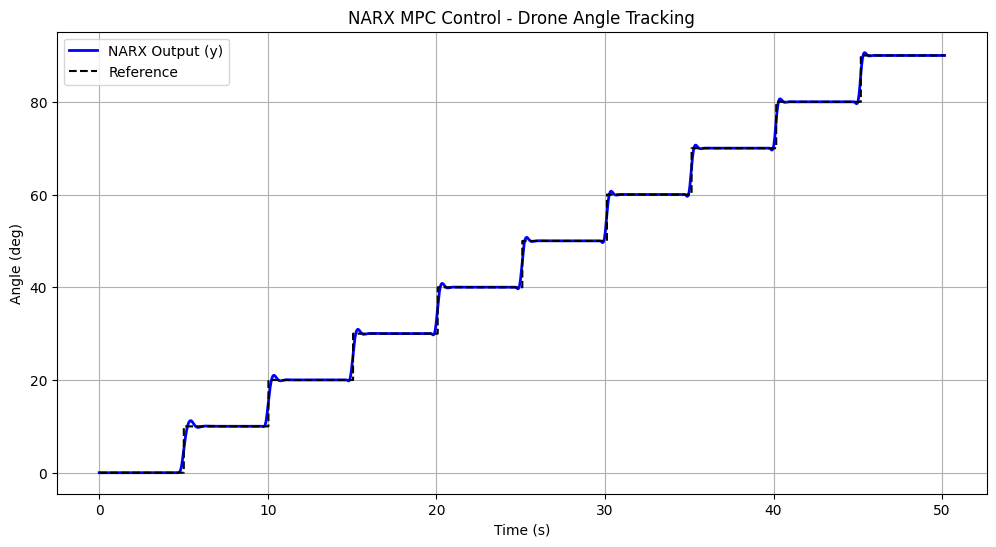

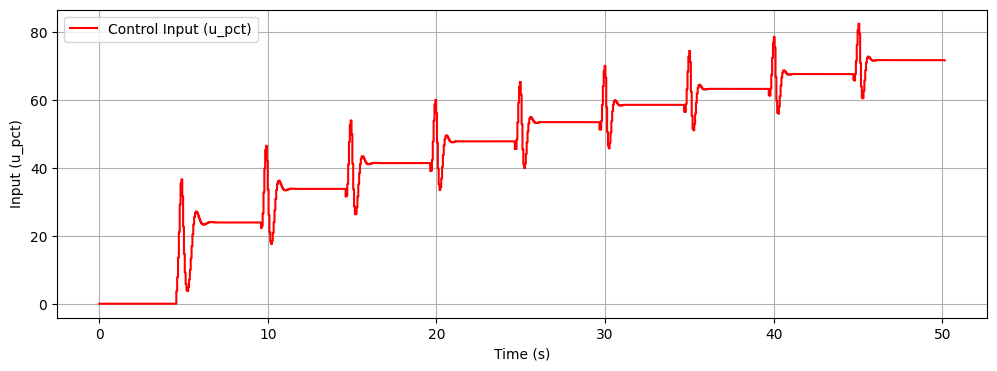

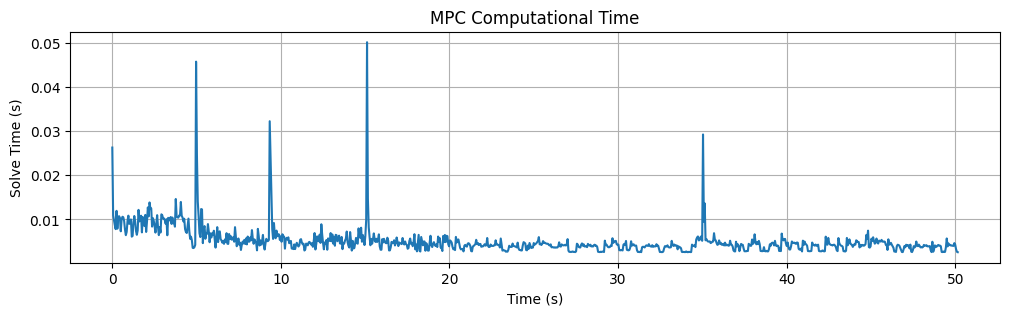

In [18]:
# 6. Plotting Results
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim, ysim, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim, x2ref[:len(tvec_sim)], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Drone Angle Tracking')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(tvec_sim, usim, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(tvec_sim, dtvec)
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Solve Time (s)')
plt.title('MPC Computational Time')
plt.show()
